# Climate Visibility Intelligence Dashboard

# Notebook 03 - Exploratory Data Analysis (EDA)

---

## Objective

The objective of this notebook is to explore the cleaned weather dataset, discover patterns, identify relationships between variables, and generate insights that will help in feature engineering and machine learning.

---

## Input Dataset

```text
data/processed/weatherHistory_cleaned.csv
```

---

## Exploratory Analysis Goals

- Understand the distribution of the target variable (Visibility).
- Analyze numerical feature distributions.
- Explore categorical variables.
- Identify relationships between weather variables.
- Detect outliers.
- Generate insights for model building.

---

## Target Variable

**Visibility (km)**

---

## Expected Outcome

A comprehensive understanding of the cleaned dataset that will guide feature engineering and model selection.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/weatherHistory_cleaned.csv")

In [3]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,Partly cloudy throughout the day.
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,Partly cloudy throughout the day.
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,Partly cloudy throughout the day.
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,Partly cloudy throughout the day.
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,Partly cloudy throughout the day.


In [4]:
df.shape

(95912, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95912 entries, 0 to 95911
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95912 non-null  str    
 1   Summary                   95912 non-null  str    
 2   Precip Type               95912 non-null  str    
 3   Temperature (C)           95912 non-null  float64
 4   Apparent Temperature (C)  95912 non-null  float64
 5   Humidity                  95912 non-null  float64
 6   Wind Speed (km/h)         95912 non-null  float64
 7   Wind Bearing (degrees)    95912 non-null  float64
 8   Visibility (km)           95912 non-null  float64
 9   Pressure (millibars)      95912 non-null  float64
 10  Daily Summary             95912 non-null  str    
dtypes: float64(7), str(4)
memory usage: 8.0 MB


In [6]:
df["Visibility (km)"].describe()

count    95912.000000
mean        10.362306
std          4.174204
min          0.000000
25%          8.355900
50%         10.046400
75%         14.812000
max         16.100000
Name: Visibility (km), dtype: float64

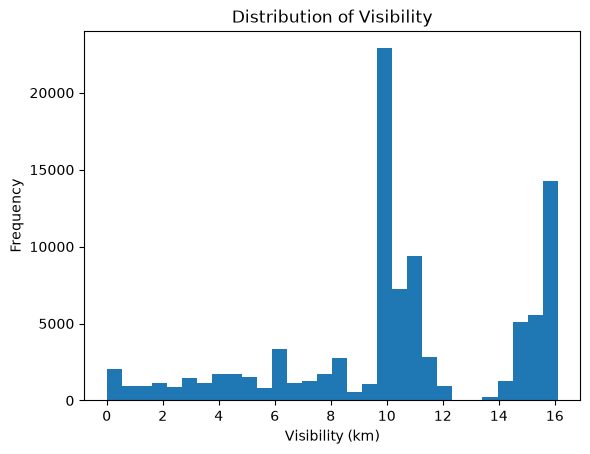

In [7]:
plt.Figure(figsize=(8,5))
plt.hist(df["Visibility (km)"],bins=30)

plt.title("Distribution of Visibility")
plt.xlabel("Visibility (km)")
plt.ylabel("Frequency")

plt.show()

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\1121415610.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Visibility (km)"],vert=False)


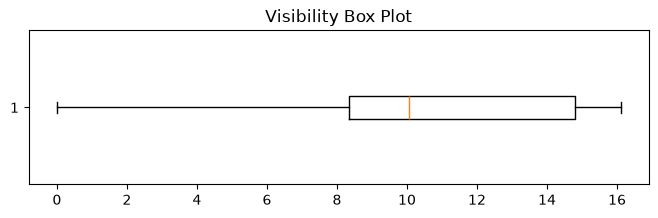

In [9]:
plt.figure(figsize=(8,2))
plt.boxplot(df["Visibility (km)"],vert=False)
plt.title("Visibility Box Plot")
plt.show()

In [10]:
df["Visibility (km)"].nunique()

949

In [11]:
numerical_columns = df.select_dtypes(include="number").columns
numerical_columns

Index(['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
       'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
       'Pressure (millibars)'],
      dtype='str')

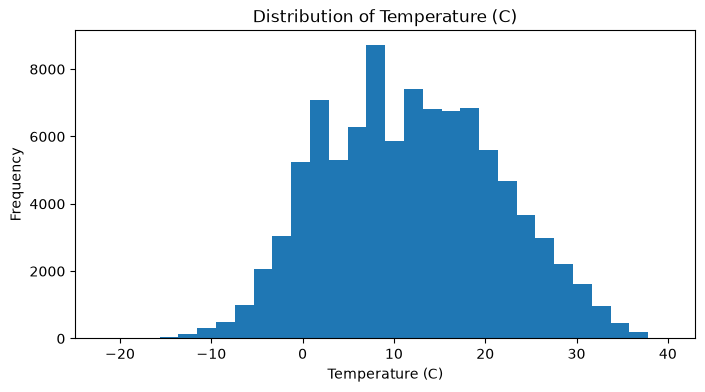

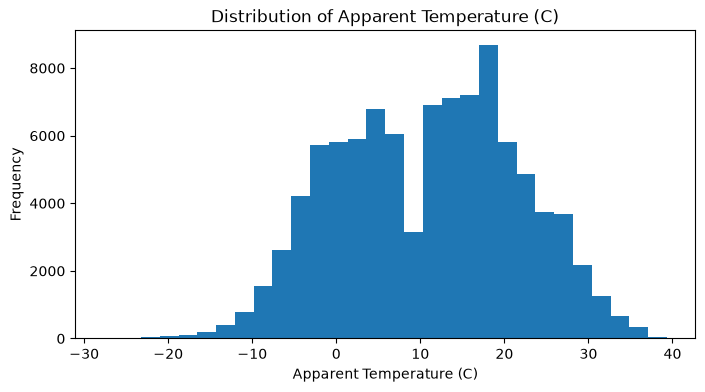

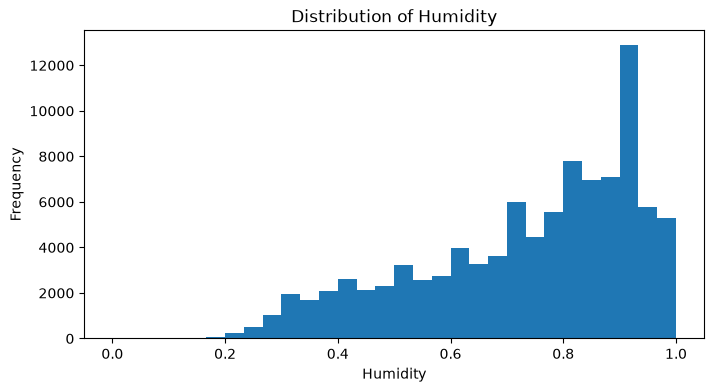

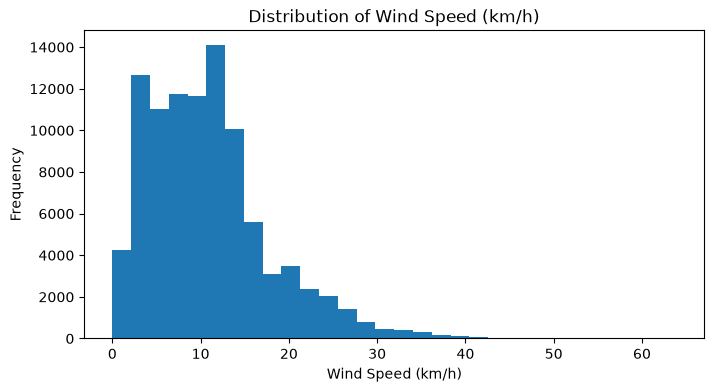

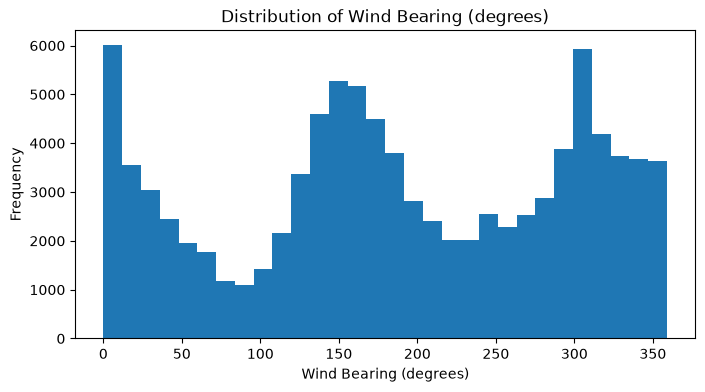

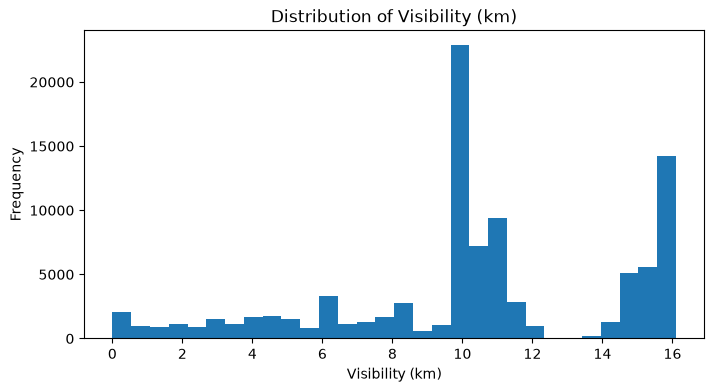

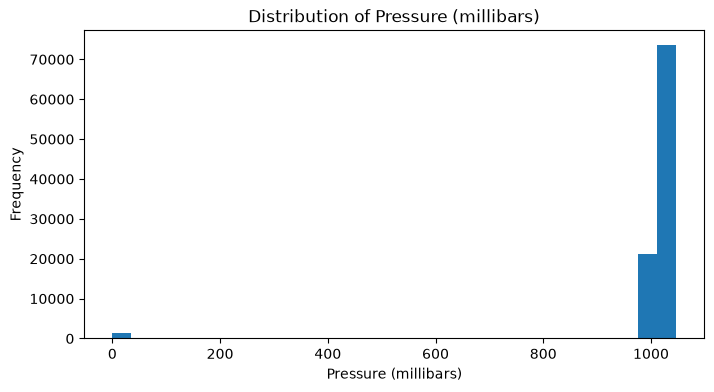

In [12]:
for col in numerical_columns:
    plt.figure(figsize=(8,4))
    plt.hist(df[col],bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show

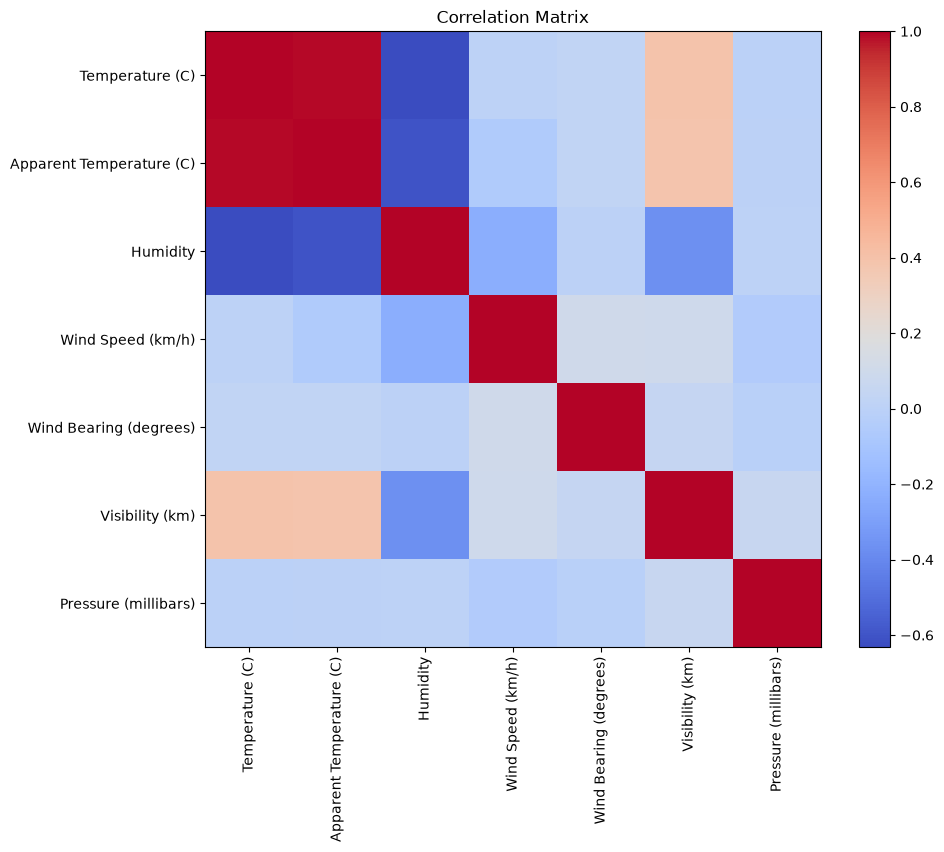

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(df.corr(numeric_only=True), cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns,
    rotation=90
)

plt.yticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns
)

plt.title("Correlation Matrix")

plt.show()

## Observations

- Temperature and Apparent Temperature have a very strong positive correlation (~0.99).
- Humidity is negatively correlated with Temperature and Visibility.
- Visibility has moderate positive correlation with Temperature and Apparent Temperature.
- Wind Speed, Wind Bearing, and Pressure show weak correlations with Visibility.
- Temperature and Apparent Temperature may introduce multicollinearity in some models and will be examined during feature selection.

In [14]:
important_features = [
    "Temperature (C)",
    "Apparent Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Pressure (millibars)"
]

important_features

['Temperature (C)',
 'Apparent Temperature (C)',
 'Humidity',
 'Wind Speed (km/h)',
 'Pressure (millibars)']

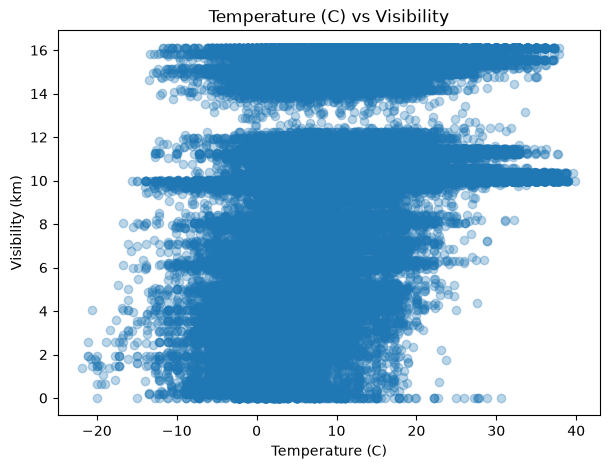

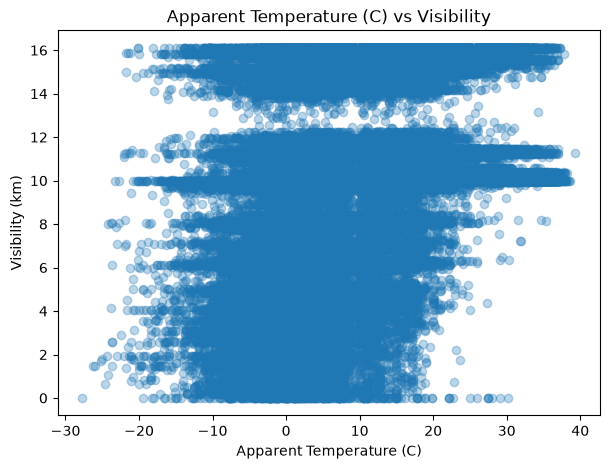

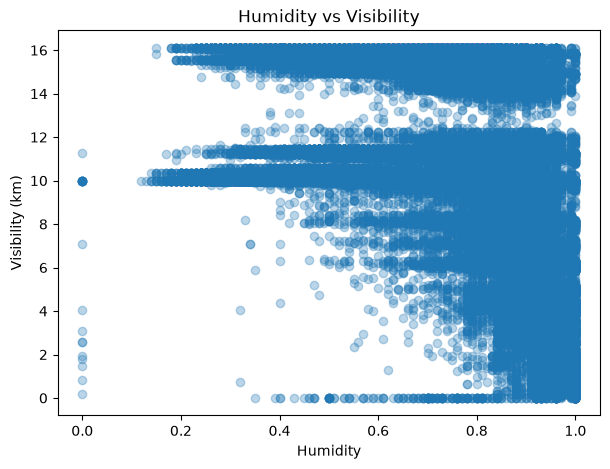

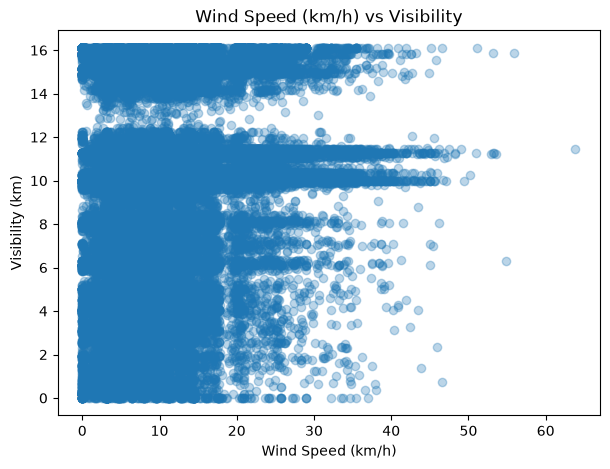

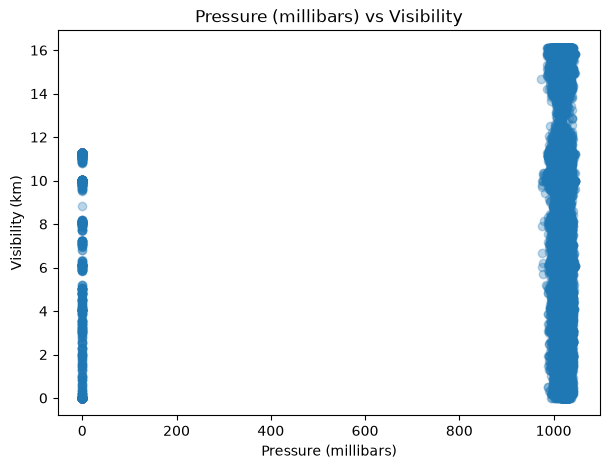

In [17]:
for feature in important_features:

    plt.figure(figsize=(7,5))

    plt.scatter(
        df[feature],
        df["Visibility (km)"],
        alpha=0.3
    )

    plt.title(f"{feature} vs Visibility")

    plt.xlabel(feature)

    plt.ylabel("Visibility (km)")

    plt.show()

## Scatter Plot Observations

- Temperature shows a moderate positive relationship with Visibility.
- Apparent Temperature follows a similar trend because it is highly correlated with Temperature.
- Humidity has a moderate negative relationship with Visibility.
- Wind Speed has only a weak relationship with Visibility.
- Pressure contains unrealistic zero values that appear as a separate cluster and should be treated during preprocessing.

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


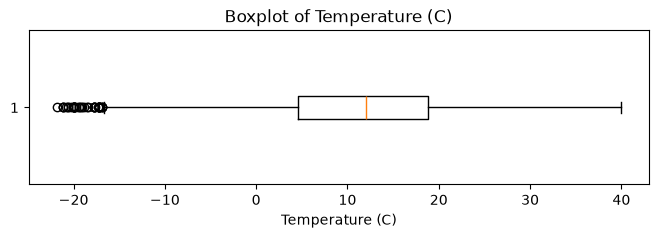

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


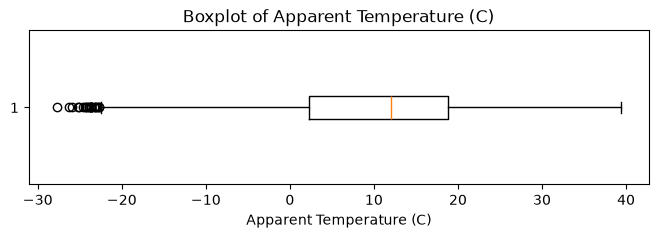

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


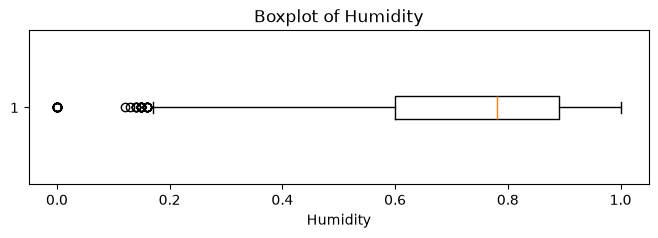

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


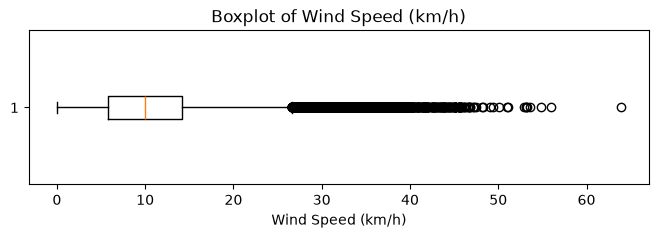

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


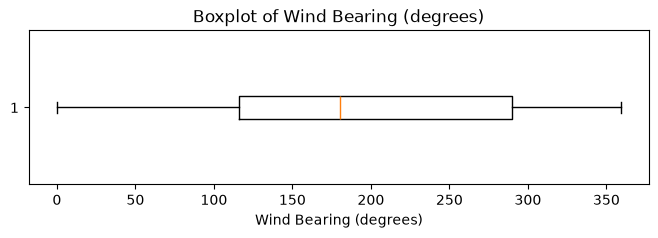

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


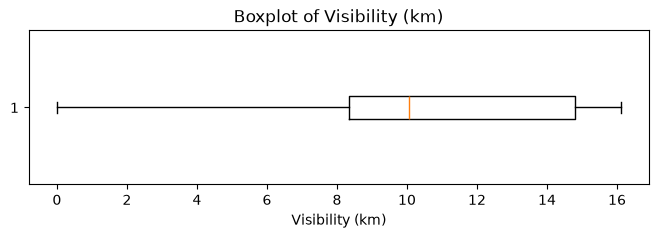

C:\Users\tanmo\AppData\Local\Temp\ipykernel_14016\2627830093.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


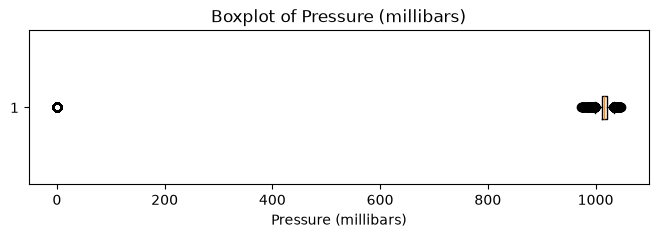

In [18]:
for col in numerical_columns:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[col], vert=False)

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.show()

# Final EDA Observations

## Outlier Analysis

- Temperature contains a few low-temperature outliers that represent real weather conditions.
- Apparent Temperature also contains realistic low-value observations.
- Humidity has a few low-value observations but they are valid.
- Wind Speed contains many high-value observations corresponding to strong winds and storms.
- Wind Bearing does not show significant outliers.
- Visibility does not contain major outliers.
- Pressure contains unrealistic zero values that require preprocessing before model training.

## Conclusion

Most observed outliers represent genuine weather events rather than data errors. Therefore, they should be retained. Only physically unrealistic measurements (such as Pressure = 0) require special treatment during preprocessing.